## **INSTALL & IMPORT LIBRARIES**

In [ ]:
# Install imbalanced-learn for SMOTE
!pip install imbalanced-learn -q

In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & modeling
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)

# Imbalanced data handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter

pd.set_option('display.max_columns', None)


## **IMPORT DATA**

In [ ]:
# Download dataset from Google Drive
!gdown --id 1kJF9lZofYG_7jAsC3vWnt87cX4xiC1Kb

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1kJF9lZofYG_7jAsC3vWnt87cX4xiC1Kb
From (redirected): https://drive.google.com/uc?id=1kJF9lZofYG_7jAsC3vWnt87cX4xiC1Kb&confirm=t&uuid=e92cc50d-c41a-457a-86b8-1e8557d4ef1c
To: /content/loan_data_2007_2014.csv
100% 240M/240M [00:04<00:00, 54.1MB/s]


In [ ]:
# Read CSV into DataFrame, first column as index
data = pd.read_csv('loan_data_2007_2014.csv', index_col=0)

## **EXPLORE DATA**

In [ ]:
# Check the number of rows and columns in the dataset
data.shape

(466285, 74)

In [ ]:
# View data types and non-null counts per column
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 466285 entries, 0 to 466284
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           466285 non-null  int64  
 1   member_id                    466285 non-null  int64  
 2   loan_amnt                    466285 non-null  int64  
 3   funded_amnt                  466285 non-null  int64  
 4   funded_amnt_inv              466285 non-null  float64
 5   term                         466285 non-null  object 
 6   int_rate                     466285 non-null  float64
 7   installment                  466285 non-null  float64
 8   grade                        466285 non-null  object 
 9   sub_grade                    466285 non-null  object 
 10  emp_title                    438697 non-null  object 
 11  emp_length                   445277 non-null  object 
 12  home_ownership               466285 non-null  object 
 13  annu

In [ ]:
# Display 1 random row for an initial overview of the data
data.sample()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
279,1062094,1294147,5000,5000,5000.0,36 months,12.42,167.08,B,B4,BBVA Compass,2 years,RENT,70000.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,debt_consolidation,Debt Consolidation Loan,785xx,TX,20.06,0.0,Mar-04,1.0,NaN,NaN,14.0,0.0,13543,54.2,26.0,f,0.0,0.0,5501.16,5501.16,5000.0,501.16,0.0,0.0,0.0,Nov-12,3833.62,NaN,Jul-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Check ID uniqueness — should equal number of rows if IDs are unique
print(f'Unique loan IDs   : {data.id.nunique()}')
print(f'Unique member IDs : {data.member_id.nunique()}')

Unique loan IDs   : 466285
Unique member IDs : 466285


## **REMOVE USELESS FEATURES**

In [ ]:
# Columns to drop:
# - Identifiers (id, member_id): no predictive value
# - Free-text / URL (url, desc): noise, cannot be encoded
# - zip_code: too granular, low signal
# - Joint-account fields: mostly empty for individual loans
# - Installment loan fields (open_il_*, etc.): many missing for revolving accounts
# - sub_grade: already represented by grade
cols_to_drop = [
    'id', 'member_id', 'url', 'desc', 'zip_code',
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m',
    'mths_since_rcnt_il', 'total_bal_il', 'il_util',
    'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
    'inq_fi', 'total_cu_tl', 'inq_last_12m', 'sub_grade'
]

In [ ]:
# Drop the listed columns along the column axis (axis=1)
# axis=1 --> delete a column
# axis=0 --> delete a row (default)
new_data = data.drop(cols_to_drop, axis=1)

In [ ]:
# Preview 5 random rows of the cleaned dataset
new_data.sample(5)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,purpose,title,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
422972,6175,6175,6175.0,36 months,15.61,215.91,C,Police Officer,4 years,MORTGAGE,35000.0,Not Verified,Mar-14,Current,n,debt_consolidation,Debt consolidation,MI,10.77,0.0,Aug-07,1.0,62.0,13.0,6.0,1.0,3527,43.0,6.0,f,2924.98,2924.98,4534.11,4534.11,3250.02,1284.09,0.0,0.0,0.0,Dec-15,215.91,Feb-16,Jan-16,0.0,112.0,1,INDIVIDUAL,0.0,0.0,93026.0,8200.0
33306,8750,8750,8700.0,36 months,7.74,273.17,A,Core Fit,2 years,RENT,150000.0,Not Verified,Dec-09,Fully Paid,n,other,Biology Grad Student looking for personal loan,NV,0.90,0.0,Nov-75,0.0,NaN,NaN,6.0,0.0,5016,17.9,7.0,f,0.00,0.00,9288.68,9235.60,8750.00,538.68,0.0,0.0,0.0,Jan-12,10.41,NaN,Jan-12,0.0,NaN,1,INDIVIDUAL,0.0,NaN,NaN,NaN
59717,5600,5600,5550.0,60 months,11.99,124.55,B,System Administrator,< 1 year,RENT,62400.0,Verified,Dec-13,Current,n,major_purchase,DebtConsolidation,VA,7.12,0.0,Mar-02,0.0,NaN,NaN,2.0,0.0,1939,62.5,5.0,f,2655.89,2632.18,4112.41,4075.68,2944.11,1168.30,0.0,0.0,0.0,Jan-16,124.55,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,0.0,0.0,5780.0,3100.0
351040,5000,5000,5000.0,36 months,14.49,172.09,C,Table Games Shift Manager,10+ years,MORTGAGE,100000.0,Source Verified,Jul-14,Fully Paid,n,vacation,Vacation,CA,9.35,1.0,Mar-05,0.0,14.0,NaN,7.0,0.0,11509,78.8,15.0,f,0.00,0.00,5670.55,5670.55,5000.00,670.55,0.0,0.0,0.0,Jul-15,3777.56,NaN,Dec-15,0.0,14.0,1,INDIVIDUAL,0.0,0.0,290696.0,14600.0
266125,14400,14400,14400.0,60 months,14.49,338.74,C,Grounds keeper,10+ years,RENT,38000.0,Source Verified,Nov-14,Current,n,credit_card,Credit card refinancing,OR,39.67,0.0,Oct-97,0.0,NaN,NaN,14.0,0.0,11750,58.5,22.0,w,11901.76,11901.76,4730.77,4730.77,2498.24,2232.53,0.0,0.0,0.0,Jan-16,338.74,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,0.0,0.0,49209.0,20100.0


## **DEFINE TARGET VARIABLE / LABELING**

In [ ]:
# View loan status distribution before labeling
new_data.loan_status.value_counts()

,count
loan_status,
Current,224226
Fully Paid,184739
Charged Off,42475
Late (31-120 days),6900
In Grace Period,3146
Does not meet the credit policy. Status:Fully Paid,1988
Late (16-30 days),1218
Default,832
Does not meet the credit policy. Status:Charged Off,761


In [ ]:
# Statuses categorized as "bad loan"
bad_status = [
    'Charged Off', 'Default',
    'Does not meet the credit policy. Status: Charged Off',
    'Late (31-120 days)'
]

In [ ]:
# Create binary target column: 1 = bad loan, 0 = good loan
new_data['status_loan'] = np.where(new_data['loan_status'].isin(bad_status), 1, 0)

In [ ]:
# Verify target distribution
new_data['status_loan'].value_counts()

,count
status_loan,
0,416078
1,50207


In [ ]:
# Remove the original loan_status text column since we now have the binary target
# inplace=True --> modifies the DataFrame directly instead of returning a new one
new_data.drop('loan_status', axis=1, inplace=True)

## **CLEANING, PRE-PROCESSING, FEATURE ENGINEERING**

### emp_length

In [ ]:
# Inspect the unique values in the employment length column (e.g., '10+ years', '< 1 year')
new_data['emp_length'].unique()

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years', nan],
      dtype=object)

In [ ]:
# Extract number from emp_length string (e.g. '10+ years' → 10)
# r'[^0-9]+' = remove all non-digit characters
new_data['emp_length_int'] = new_data['emp_length'].str.replace(r'[^0-9]+', '', regex=True).astype(float)

In [ ]:
# Preview the new numeric column
new_data['emp_length_int']

,emp_length_int
0,10.0
1,1.0
2,10.0
3,10.0
4,1.0
...,...
466280,4.0
466281,10.0
466282,7.0
466283,3.0


In [ ]:
# Drop the original text column since we have the numeric version
new_data.drop('emp_length', axis=1, inplace=True)

### term

In [ ]:
# Inspect unique values in the loan term column (e.g., ' 36 months', ' 60 months')
new_data['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [ ]:
# Extract number from term column (e.g. ' 36 months' → 36.0)
new_data['term_int'] = new_data['term'].str.replace(' months', '').astype(float)

In [ ]:
# Preview the new numeric column
new_data['term_int']

,term_int
0,36.0
1,60.0
2,36.0
3,36.0
4,60.0
...,...
466280,60.0
466281,60.0
466282,60.0
466283,36.0


In [ ]:
# Drop the original text column
new_data.drop('term', axis=1, inplace=True)

### Convert date columns to months elapsed

In [ ]:
# Reference date = end of dataset window
ref_date = pd.to_datetime('2014-12-01')

In [ ]:
def date_to_months(series, fmt='%b-%y'):
    """
    Convert date column (format 'Mon-YY') to number of months since ref_date.
    Transforms absolute dates into relative numeric features.
    """
    parsed = pd.to_datetime(series, format=fmt)

    # Day difference divided by average days per month (30.44)
    return round(pd.to_numeric((ref_date - parsed) / np.timedelta64(1, 'D')) / 30.44)

In [ ]:
# Convert earliest_cr_line
new_data['mths_since_earliest_cr_line'] = date_to_months(new_data['earliest_cr_line'])

In [ ]:
new_data['mths_since_earliest_cr_line']

,mths_since_earliest_cr_line
0,359.0
1,188.0
2,157.0
3,226.0
4,227.0
...,...
466280,140.0
466281,210.0
466282,156.0
466283,142.0


In [ ]:
# Fix 2-digit years misinterpreted (e.g. '68' → 2068 → negative values)
# Replace negative values with the maximum valid value
new_data.loc[new_data['mths_since_earliest_cr_line'] < 0, 'mths_since_earliest_cr_line'] = \
    new_data['mths_since_earliest_cr_line'].max()

In [ ]:
# Convert remaining date columns
new_data['mths_since_issue_d']            = date_to_months(new_data['issue_d'])
new_data['mths_since_last_pymnt_d']       = date_to_months(new_data['last_pymnt_d'])
new_data['mths_since_next_pymnt_d']       = date_to_months(new_data['next_pymnt_d'])
new_data['mths_since_last_credit_pull_d'] = date_to_months(new_data['last_credit_pull_d'])

In [ ]:
# Drop original date columns
new_data.drop(['earliest_cr_line', 'issue_d', 'last_pymnt_d',
               'next_pymnt_d', 'last_credit_pull_d'], axis=1, inplace=True)

## **EXPLORATORY DATA ANALYSIS**

### Correlation Check

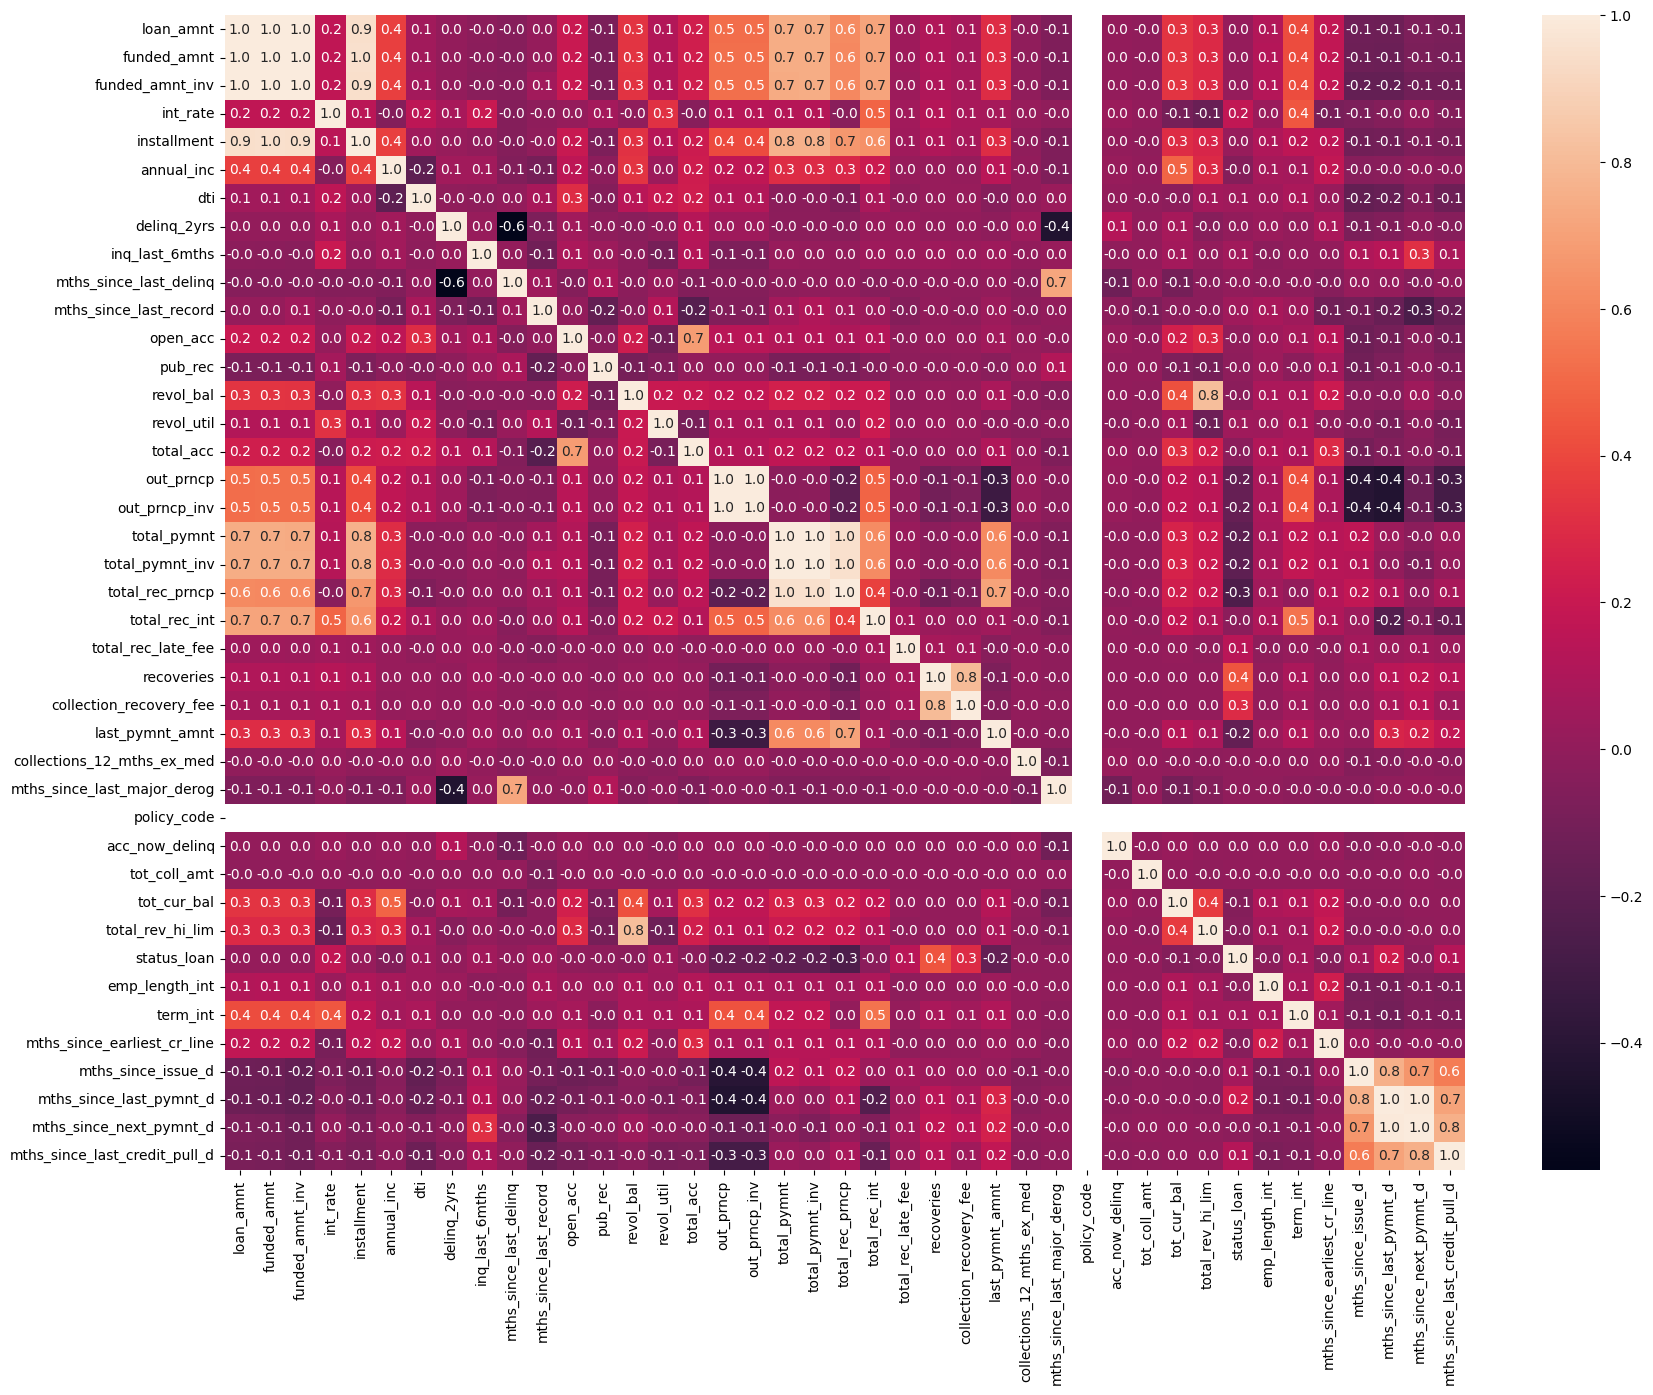

In [ ]:
# Correlation heatmap for all numeric features
plt.figure(figsize=(20, 15))
sns.heatmap(new_data.select_dtypes(include=np.number).corr(), annot=True, fmt='.1f')
plt.show()

In [ ]:
# Identify feature pairs with absolute correlation > 0.7 (highly correlated)
# Use upper triangle of matrix to avoid duplicate pairs
corr_matrix = new_data.select_dtypes(include=np.number).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

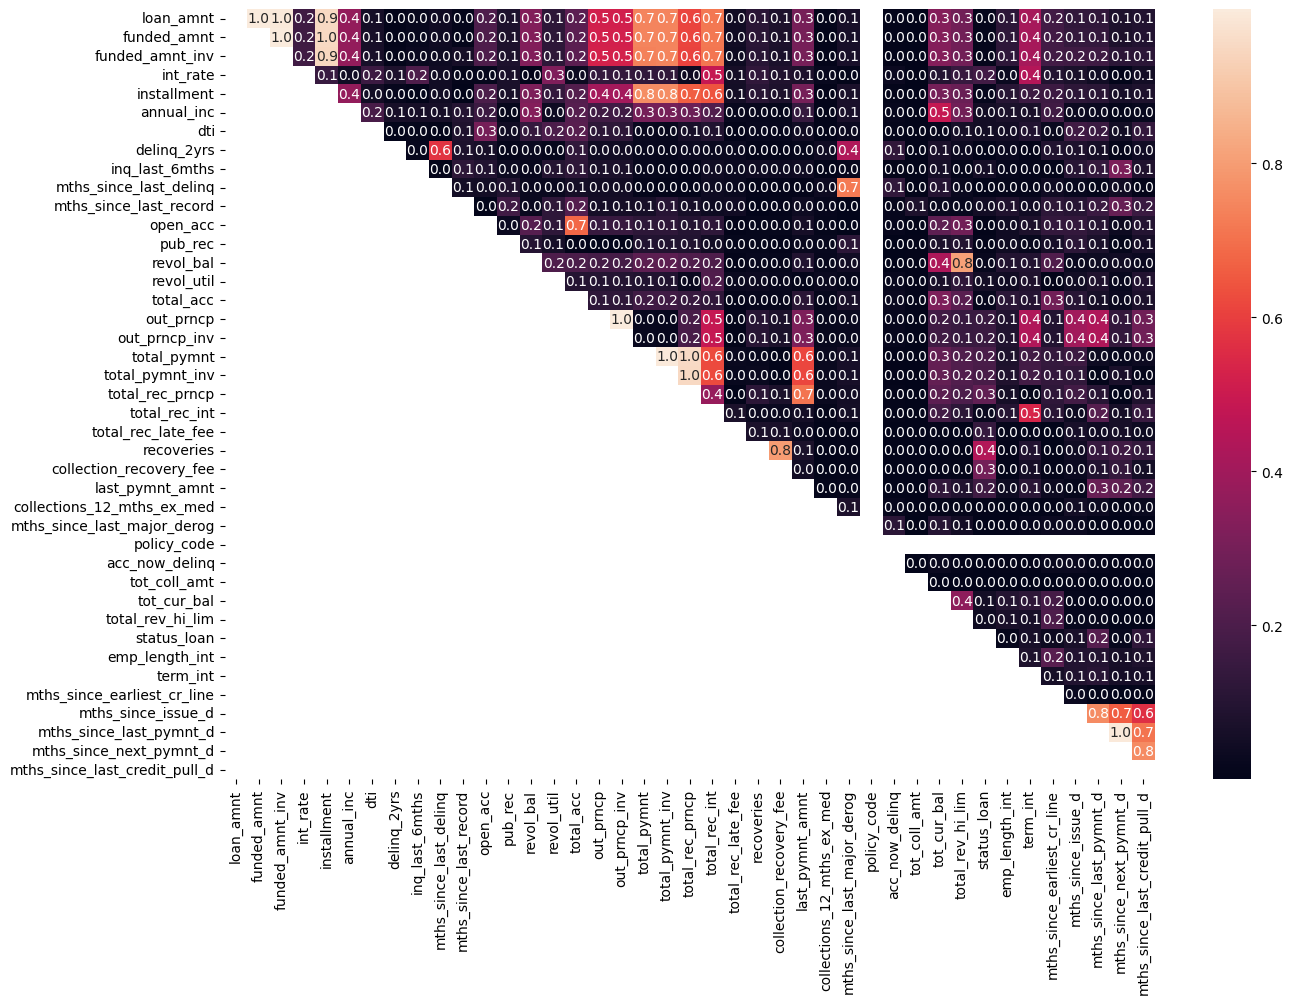

In [ ]:
# Visualize the upper triangle
plt.figure(figsize=(15, 10))
sns.heatmap(upper, annot=True, fmt='.1f')
plt.show()

In [ ]:
# Collect columns with correlation > 0.7
to_drop_hicorr = [col for col in upper.columns if any(upper[col] > 0.7)]

In [ ]:
# Inspect which columns will be dropped due to high correlation
print('Columns dropped due to high correlation:', to_drop_hicorr)

Columns dropped due to high correlation: ['funded_amnt', 'funded_amnt_inv', 'installment', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'collection_recovery_fee', 'last_pymnt_amnt', 'mths_since_last_major_derog', 'total_rev_hi_lim', 'mths_since_last_pymnt_d', 'mths_since_next_pymnt_d', 'mths_since_last_credit_pull_d']


In [ ]:
# Remove the highly correlated columns to reduce multicollinearity
new_data.drop(to_drop_hicorr, axis=1, inplace=True)

### Check Categorical Features

In [ ]:
# Number of unique values per categorical and numerical column
print('Categorical columns:')
print(new_data.select_dtypes(include='object').nunique())
print('\nNumerical columns:')
print(new_data.select_dtypes(exclude='object').nunique())

Categorical columns:
grade                       7
emp_title              205475
home_ownership              6
verification_status         3
pymnt_plan                  2
purpose                    14
title                   63098
addr_state                 50
initial_list_status         2
application_type            1
dtype: int64

Numerical columns:
loan_amnt                        1352
int_rate                          506
annual_inc                      31901
dti                              3997
delinq_2yrs                        24
inq_last_6mths                     28
mths_since_last_delinq            145
mths_since_last_record            123
open_acc                           62
pub_rec                            26
revol_bal                       58142
revol_util                       1269
total_acc                         112
out_prncp                      135665
total_rec_late_fee               5808
recoveries                      22773
collections_12_mths_ex_med          9


In [ ]:
# Drop low-value categorical columns:
# - emp_title, title : very high cardinality, difficult to encode
# - application_type, policy_code, pymnt_plan : only 1 unique value (zero variance)
new_data.drop(['emp_title', 'title', 'application_type', 'policy_code', 'pymnt_plan'], axis=1, inplace=True)

## **HANDLE MISSING VALUES**

In [ ]:
# Percentage of missing values per column (only show columns with missing data)
check_missing = new_data.isnull().sum() * 100 / new_data.shape[0]
check_missing[check_missing > 0].sort_values(ascending=False)

,0
mths_since_last_record,86.566585
mths_since_last_delinq,53.690554
tot_cur_bal,15.071469
tot_coll_amt,15.071469
emp_length_int,4.505399
revol_util,0.072917
collections_12_mths_ex_med,0.031097
delinq_2yrs,0.006219
pub_rec,0.006219
inq_last_6mths,0.006219


In [ ]:
# Drop mths_since_last_record: >75% missing, signal too weak
new_data.drop('mths_since_last_record', axis=1, inplace=True)

In [ ]:
# Fill annual_inc with mean (reasonable central estimate)
new_data['annual_inc'].fillna(new_data['annual_inc'].mean(), inplace=True)

In [ ]:
# Fill count/frequency columns with 0 — NaN means "never occurred"
fill_zero = ['mths_since_earliest_cr_line', 'acc_now_delinq', 'total_acc',
             'pub_rec', 'open_acc', 'inq_last_6mths', 'delinq_2yrs',
             'collections_12_mths_ex_med', 'revol_util', 'emp_length_int',
             'tot_cur_bal', 'tot_coll_amt']

for col in fill_zero:
    if col in new_data.columns:
        new_data[col].fillna(0, inplace=True)

In [ ]:
# Fill mths_since_last_delinq with -1 as sentinel for "never delinquent"
# (different from 0 which means "0 months ago")
new_data['mths_since_last_delinq'].fillna(-1, inplace=True)

In [ ]:
print(f'Shape after cleaning: {new_data.shape}')

Shape after cleaning: (466285, 30)


## **FEATURE SCALING & TRANSFORMATION**

### One-Hot Encoding

In [ ]:
# Identify categorical columns
categorical_cols = new_data.select_dtypes(include='object').columns.tolist()

In [ ]:
# One-hot encoding — drop_first=True to avoid dummy variable trap
onehot = pd.get_dummies(new_data[categorical_cols], drop_first=True)

In [ ]:
onehot.head()

,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,addr_state_AL,addr_state_AR,addr_state_AZ,addr_state_CA,addr_state_CO,addr_state_CT,addr_state_DC,addr_state_DE,addr_state_FL,addr_state_GA,addr_state_HI,addr_state_IA,addr_state_ID,addr_state_IL,addr_state_IN,addr_state_KS,addr_state_KY,addr_state_LA,addr_state_MA,addr_state_MD,addr_state_ME,addr_state_MI,addr_state_MN,addr_state_MO,addr_state_MS,addr_state_MT,addr_state_NC,addr_state_NE,addr_state_NH,addr_state_NJ,addr_state_NM,addr_state_NV,addr_state_NY,addr_state_OH,addr_state_OK,addr_state_OR,addr_state_PA,addr_state_RI,addr_state_SC,addr_state_SD,addr_state_TN,addr_state_TX,addr_state_UT,addr_state_VA,addr_state_VT,addr_state_WA,addr_state_WI,addr_state_WV,addr_state_WY,initial_list_status_w
0,True,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


### Standardization

In [ ]:
# Numerical columns (excluding categorical and target)
numerical_cols = [col for col in new_data.columns if col not in categorical_cols + ['status_loan']]

## **MODELING**

XGBoost, Random Forest, and Logistic Regression are commonly used models in credit risk analysis.

These three models are selected to serve different purposes:
1. Gradient Boosting is effective at identifying borderline cases that are often difficult to detect.
2. Random Forest handles noisy or complex data robustly.
3. Logistic Regression provides
transparency for regulatory auditing.

Together, they offer complementary strengths that address key challenges in credit risk modeling.

### Train-Test Split

In [ ]:
# Separate features and target
# Split BEFORE scaling to prevent data leakage from the test set
X_cat = onehot
X_num = new_data[numerical_cols]
y     = new_data['status_loan']

In [ ]:
# 80% train, 20% test — stratify=y ensures class ratio is preserved in both sets
X_cat_train, X_cat_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_cat, X_num, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Fit scaler on training data only to prevent data leakage (transform test set with same scaler)
ss = StandardScaler()
X_num_train_scaled = pd.DataFrame(ss.fit_transform(X_num_train), columns=numerical_cols, index=X_num_train.index)
X_num_test_scaled  = pd.DataFrame(ss.transform(X_num_test),      columns=numerical_cols, index=X_num_test.index)

In [ ]:
# Concatenate categorical and numerical features
X_train = pd.concat([X_cat_train.reset_index(drop=True), X_num_train_scaled.reset_index(drop=True)], axis=1)
X_test  = pd.concat([X_cat_test.reset_index(drop=True),  X_num_test_scaled.reset_index(drop=True)],  axis=1)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

In [ ]:
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Class distribution in train:\n{y_train.value_counts(normalize=True)*100}')

Train: (373028, 99), Test: (93257, 99)
Class distribution in train:
status_loan
0    89.232444
1    10.767556
Name: proportion, dtype: float64


### Handle Imbalance Data (SMOTE)



In [ ]:
# Check class distribution and imbalance ratio BEFORE SMOTE
counter_before = Counter(y_train)
ratio = counter_before[0] / counter_before[1]

In [ ]:
print(f'Class distribution BEFORE SMOTE: {counter_before}')
print(f'Imbalance ratio: {ratio:.2f}:1  (for every 1 bad loan there are {ratio:.1f} good loans)')

Class distribution BEFORE SMOTE: Counter({0: 332862, 1: 40166})
Imbalance ratio: 8.29:1  (for every 1 bad loan there are 8.3 good loans)


In [ ]:
# Visualize class distribution before vs after SMOTE
# (run after applying SMOTE below so both charts can be shown side by side)

# Apply SMOTE to the training set
# - sampling_strategy='auto' → oversample minority class until balanced 1:1
# - k_neighbors=5            → number of nearest neighbors for interpolation
# - random_state=42          → seed for reproducibility
smote = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
counter_after = Counter(y_train_smote)
added = counter_after[1] - counter_before[1]

In [ ]:
print(f'Class distribution AFTER SMOTE : {counter_after}')
print(f'Synthetic samples added        : {added:,}')
print(f'Training set size before       : {len(y_train):,}')
print(f'Training set size after        : {len(y_train_smote):,}')

Class distribution AFTER SMOTE : Counter({0: 332862, 1: 332862})
Synthetic samples added        : 292,696
Training set size before       : 373,028
Training set size after        : 665,724


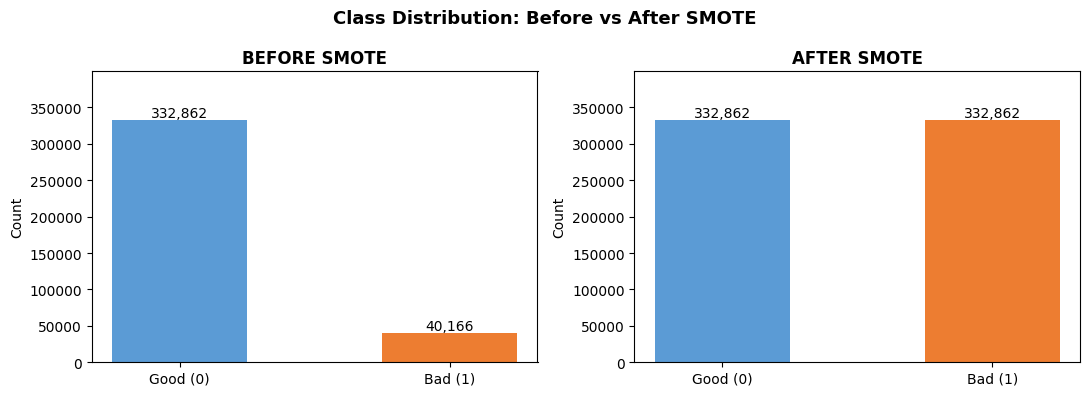

In [ ]:
# Visualize class distribution comparison before vs after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#5B9BD5', '#ED7D31']

for ax, counts, title in zip(
    axes,
    [pd.Series(y_train).value_counts(), pd.Series(y_train_smote).value_counts()],
    ['BEFORE SMOTE', 'AFTER SMOTE']
):
    bars = ax.bar(['Good (0)', 'Bad (1)'], counts.values, color=colors, width=0.5)
    for bar, c in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{c:,}', ha='center', va='bottom', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.2)

plt.suptitle('Class Distribution: Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Train Model

In this dataset, bad loans make up only a small portion of the data. This means that if no adjustment is made, the model might simply predict “good loan” for most cases and still appear accurate, even though it misses risky borrowers. This can be dangerous in real-world use.

To address this, **two approaches are compared**
1. **class weighting**, which keeps the data unchanged but makes the model give more importance to mistakes on bad loans.
2. **SMOTE**, which creates synthetic examples of bad loans to balance the dataset and provide more patterns for the model to learn from.

#### Train 3 Models - Original (Baseline)

Baseline models use `class_weight='balanced'` as a comparison against SMOTE.


In [ ]:
# Train 3 baseline models on the ORIGINAL data (without SMOTE)
# class_weight='balanced' → class weights adjusted automatically
gb = GradientBoostingClassifier(random_state=42)
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
for name, model in [('Gradient Boosting', gb), ('Random Forest', rf), ('Logistic Regression', lr)]:
    model.fit(X_train, y_train)
    print(f'{name}: training complete ✓')

Gradient Boosting: training complete ✓
Random Forest: training complete ✓
Logistic Regression: training complete ✓


#### Train 3 Models - SMOTE

The same models trained on SMOTE-balanced data.


In [ ]:
# Train 3 models on SMOTE data (balanced)
# No class_weight needed — SMOTE already balanced the class distribution
gb_smote = GradientBoostingClassifier(random_state=42)
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
lr_smote = LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
for name, model in [('Gradient Boosting (SMOTE)', gb_smote),
                    ('Random Forest (SMOTE)', rf_smote),
                    ('Logistic Regression (SMOTE)', lr_smote)]:
    model.fit(X_train_smote, y_train_smote)
    print(f'{name}: training complete ✓')

Gradient Boosting (SMOTE): training complete ✓
Random Forest (SMOTE): training complete ✓
Logistic Regression (SMOTE): training complete ✓


##**EVALUATION**

Metrics used for evaluation:
1. AUC: Measures how well the model distinguishes between good and bad loans.
2. KS: Shows how clearly the model separates risky vs non-risky borrowers.
3. Threshold: Defines the cutoff for decision-making (approve/reject).
4. Precision: Indicates how many predicted bad loans are actually bad.
5. Recall: Measures how many bad loans are correctly identified (very important in credit risk).
6. F1 Score: Balances Precision and Recall.
7. FNR: Shows how many bad loans are missed, which is critical since missing them leads to losses.

These metrics are used because they reflect both model performance and business risk, not just accuracy.

### AUC & KS Statistic

**AUC (Area Under ROC Curve)**: measures the model's ability to distinguish between positive and negative classes. Values close to 1 = better

**KS (Kolmogorov-Smirnov) Statistic**: measures the maximum separation between the cumulative predicted probability distributions for 'bad' and 'good' classes. Higher = better discrimination.


In [ ]:
def compute_ks(y_true, y_prob):
    """Compute KS statistic — maximum separation between CDF of bad and good classes."""
    df = pd.DataFrame({'y_actual': y_true, 'y_prob': y_prob})
    df = df.sort_values('y_prob').reset_index(drop=True)
    n_bad  = df['y_actual'].sum()
    n_good = len(df) - n_bad
    df['cum_bad']  = df['y_actual'].cumsum() / n_bad
    df['cum_good'] = (df.index + 1 - df['y_actual'].cumsum()) / n_good
    return (df['cum_good'] - df['cum_bad']).max()

In [ ]:
# Evaluate all 6 models — original and SMOTE
# Always evaluate on the ORIGINAL test set (not SMOTE-resampled)
all_models = {
    'Gradient Boosting':              gb,
    'Random Forest':                  rf,
    'Logistic Regression':            lr,
    'Gradient Boosting (SMOTE)':      gb_smote,
    'Random Forest (SMOTE)':          rf_smote,
    'Logistic Regression (SMOTE)':    lr_smote,
}

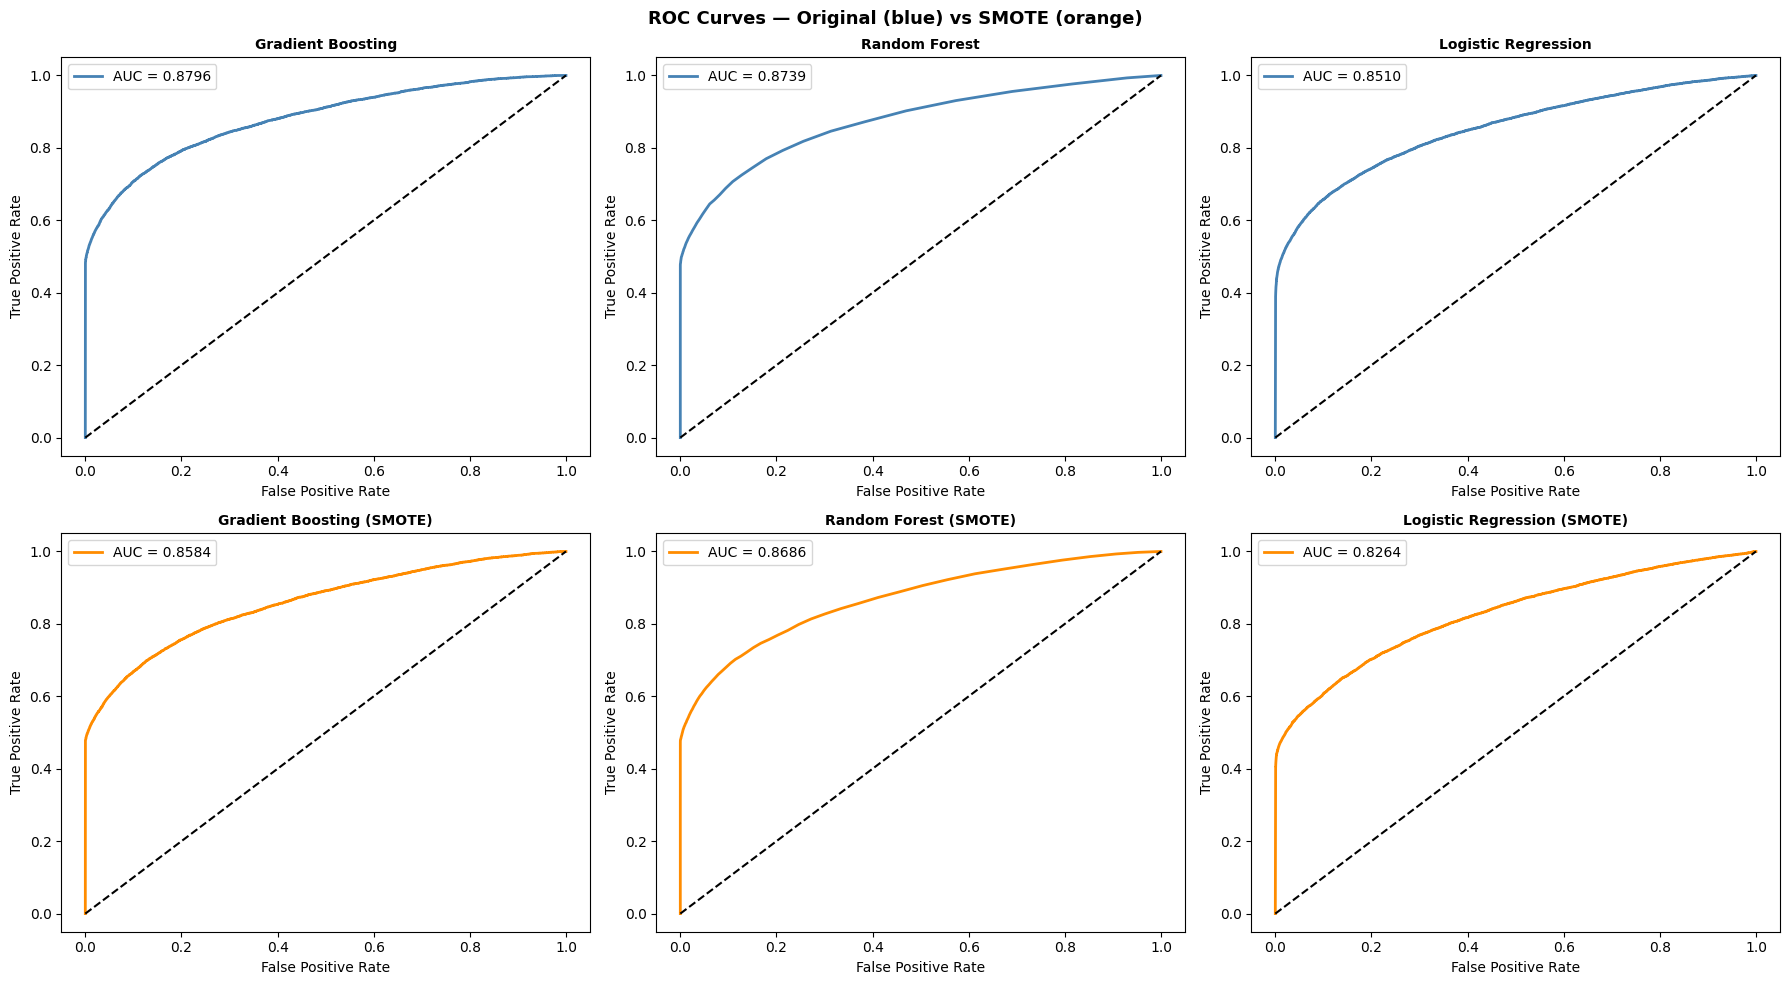

In [ ]:
results = {}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(all_models.items()):
    y_prob = model.predict_proba(X_test)[:, 1]  # probability of class 1 (bad loan)
    auc    = roc_auc_score(y_test, y_prob)
    ks     = compute_ks(y_test.values, y_prob)
    results[name] = {'AUC': auc, 'KS': ks, 'y_prob': y_prob}

    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    color = 'steelblue' if '(SMOTE)' not in name else 'darkorange'
    axes[i].plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc:.4f}')
    axes[i].plot([0, 1], [0, 1], 'k--')  # baseline random classifier
    axes[i].set_title(name, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend()

plt.suptitle('ROC Curves — Original (blue) vs SMOTE (orange)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Summarize AUC and KS for all models into a DataFrame
df_results = pd.DataFrame(
    {k: {'AUC': v['AUC'], 'KS': v['KS']} for k, v in results.items()}
).T

In [ ]:
# Print the summary table sorted by AUC (best model at the top)
print('Summary AUC & KS (sorted by AUC):')
df_results.sort_values('AUC', ascending=False).round(4)

Summary AUC & KS (sorted by AUC):


,AUC,KS
Gradient Boosting,0.8796,0.6088
Random Forest,0.8739,0.5982
Random Forest (SMOTE),0.8686,0.5882
Gradient Boosting (SMOTE),0.8584,0.5710
Logistic Regression,0.8510,0.5594
Logistic Regression (SMOTE),0.8264,0.5114


### Threshold Optimization

Find the optimal probability threshold based on F1-Score. In credit risk, the primary goal is to minimize False Negatives (bad loans that slip through approval), so FNR is also monitored.


In [ ]:
# Threshold range to evaluate (0.10 to 0.89, step 0.01)
thresholds = np.arange(0.1, 0.9, 0.01)

def find_best_threshold(y_true, y_prob, thresholds):
    """Find the threshold that maximizes F1-Score and return all metrics per threshold."""
    f1_list, prec_list, rec_list, fnr_list = [], [], [], []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1_list.append(f1_score(y_true, y_pred, zero_division=0))
        prec_list.append(precision_score(y_true, y_pred, zero_division=0))
        rec_list.append(recall_score(y_true, y_pred, zero_division=0))
        cm_t = confusion_matrix(y_true, y_pred)
        fn_t, tp_t = cm_t[1][0], cm_t[1][1]
        fnr_list.append(fn_t / (fn_t + tp_t) if (fn_t + tp_t) > 0 else 0)
    best_t = thresholds[np.argmax(f1_list)]
    return best_t, f1_list, prec_list, rec_list, fnr_list

In [ ]:
# Threshold optimization for original Gradient Boosting
best_threshold_orig, f1_orig, prec_orig, rec_orig, fnr_orig = \
    find_best_threshold(y_test, results['Gradient Boosting']['y_prob'], thresholds)

In [ ]:
# Threshold optimization for SMOTE Gradient Boosting
best_threshold_smote, f1_smote, prec_smote, rec_smote, fnr_smote = \
    find_best_threshold(y_test, results['Gradient Boosting (SMOTE)']['y_prob'], thresholds)

In [ ]:
print(f'Best Threshold — GB Original : {best_threshold_orig:.2f}')

Best Threshold — GB Original : 0.30


In [ ]:
print(f'Best Threshold — GB SMOTE    : {best_threshold_smote:.2f}')

Best Threshold — GB SMOTE    : 0.61


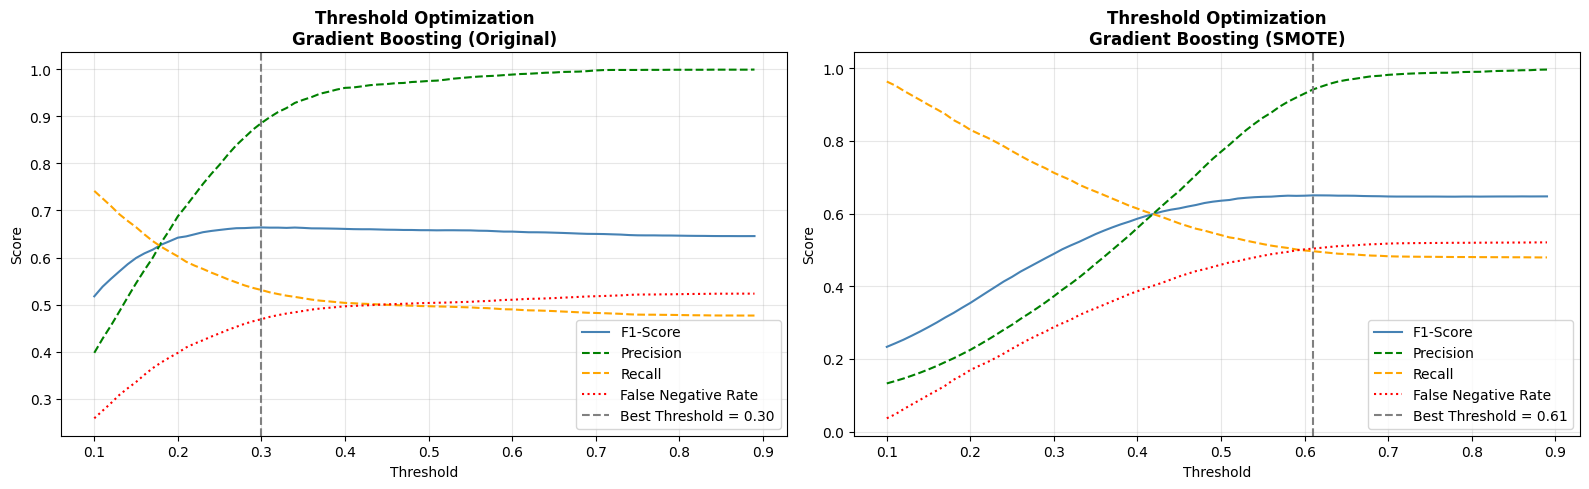

In [ ]:
# Plot threshold optimization for both models side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (f1_l, prec_l, rec_l, fnr_l, best_t, title) in zip(axes, [
    (f1_orig,  prec_orig,  rec_orig,  fnr_orig,  best_threshold_orig,  'Gradient Boosting (Original)'),
    (f1_smote, prec_smote, rec_smote, fnr_smote, best_threshold_smote, 'Gradient Boosting (SMOTE)'),
]):
    ax.plot(thresholds, f1_l,   label='F1-Score',           color='steelblue')
    ax.plot(thresholds, prec_l, label='Precision',          color='green',  linestyle='--')
    ax.plot(thresholds, rec_l,  label='Recall',             color='orange', linestyle='--')
    ax.plot(thresholds, fnr_l,  label='False Negative Rate',color='red',    linestyle=':')
    ax.axvline(best_t, color='gray', linestyle='--', label=f'Best Threshold = {best_t:.2f}')
    ax.set_title(f'Threshold Optimization\n{title}', fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Confusion Matrix & Business Metrics

In [ ]:
# Final predictions using the optimal threshold for each model
y_pred_orig_final  = (results['Gradient Boosting']['y_prob']         >= best_threshold_orig).astype(int)
y_pred_smote_final = (results['Gradient Boosting (SMOTE)']['y_prob'] >= best_threshold_smote).astype(int)

In [ ]:
cm_orig  = confusion_matrix(y_test, y_pred_orig_final)
cm_smote = confusion_matrix(y_test, y_pred_smote_final)

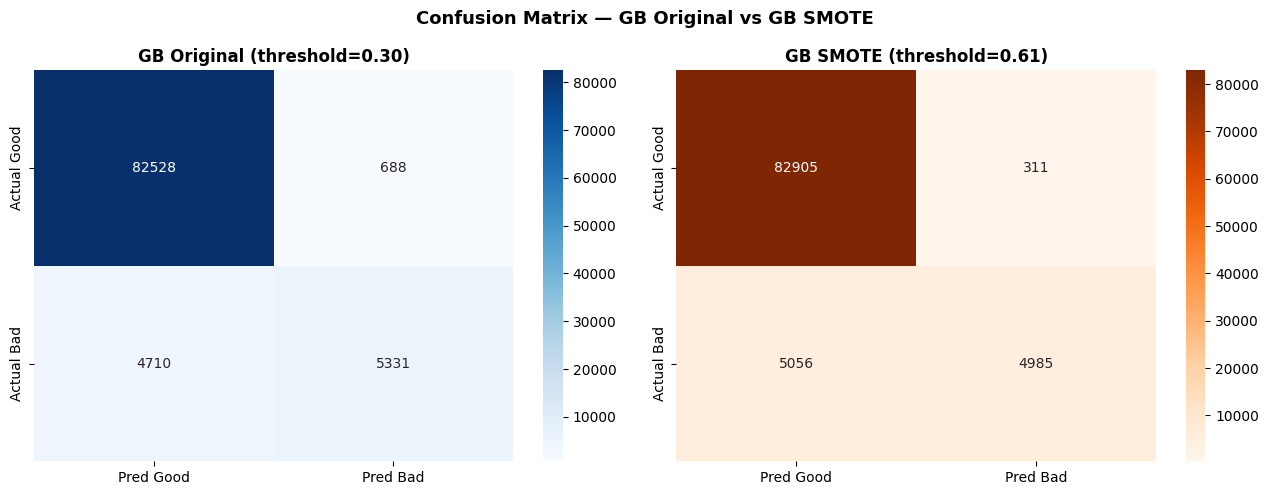

In [ ]:
# Visualize confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cm, title, cmap in zip(
    axes,
    [cm_orig, cm_smote],
    [f'GB Original (threshold={best_threshold_orig:.2f})',
     f'GB SMOTE (threshold={best_threshold_smote:.2f})'],
    ['Blues', 'Oranges']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Pred Good', 'Pred Bad'],
                yticklabels=['Actual Good', 'Actual Bad'])
    ax.set_title(title, fontweight='bold')

plt.suptitle('Confusion Matrix — GB Original vs GB SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Business metrics for both models
def print_business_metrics(cm, y_true, y_pred, label):
    tn, fp, fn, tp = cm.ravel()
    print(f'=== {label} ===')
    print(f'  True Positive  (Bad correctly caught)   : {tp:,}')
    print(f'  False Negative (Bad loan that slipped)  : {fn:,}  ← most critical!')
    print(f'  False Positive (Good wrongly rejected)  : {fp:,}')
    print(f'  True Negative  (Good correctly approved): {tn:,}')
    print(f'  Precision : {tp/(tp+fp):.4f}  → {tp/(tp+fp)*100:.1f}% of predicted bad are truly bad')
    print(f'  Recall    : {tp/(tp+fn):.4f}  → {tp/(tp+fn)*100:.1f}% of bad loans successfully caught')
    print(f'  FNR       : {fn/(fn+tp):.4f}  → {fn/(fn+tp)*100:.1f}% of bad loans slipped through approval')
    print(f'  FPR       : {fp/(fp+tn):.4f}  → {fp/(fp+tn)*100:.1f}% of good loans wrongly rejected')
    print()
    print(classification_report(y_true, y_pred, target_names=['Good', 'Bad']))

In [ ]:
print_business_metrics(cm_orig,  y_test, y_pred_orig_final,  'Gradient Boosting Original')

=== Gradient Boosting Original ===
  True Positive  (Bad correctly caught)   : 5,331
  False Negative (Bad loan that slipped)  : 4,710  ← most critical!
  False Positive (Good wrongly rejected)  : 688
  True Negative  (Good correctly approved): 82,528
  Precision : 0.8857  → 88.6% of predicted bad are truly bad
  Recall    : 0.5309  → 53.1% of bad loans successfully caught
  FNR       : 0.4691  → 46.9% of bad loans slipped through approval
  FPR       : 0.0083  → 0.8% of good loans wrongly rejected

              precision    recall  f1-score   support

        Good       0.95      0.99      0.97     83216
         Bad       0.89      0.53      0.66     10041

    accuracy                           0.94     93257
   macro avg       0.92      0.76      0.82     93257
weighted avg       0.94      0.94      0.94     93257



In [ ]:
print_business_metrics(cm_smote, y_test, y_pred_smote_final, 'Gradient Boosting SMOTE')

=== Gradient Boosting SMOTE ===
  True Positive  (Bad correctly caught)   : 4,985
  False Negative (Bad loan that slipped)  : 5,056  ← most critical!
  False Positive (Good wrongly rejected)  : 311
  True Negative  (Good correctly approved): 82,905
  Precision : 0.9413  → 94.1% of predicted bad are truly bad
  Recall    : 0.4965  → 49.6% of bad loans successfully caught
  FNR       : 0.5035  → 50.4% of bad loans slipped through approval
  FPR       : 0.0037  → 0.4% of good loans wrongly rejected

              precision    recall  f1-score   support

        Good       0.94      1.00      0.97     83216
         Bad       0.94      0.50      0.65     10041

    accuracy                           0.94     93257
   macro avg       0.94      0.75      0.81     93257
weighted avg       0.94      0.94      0.93     93257



### Head-to-Head: All Models Comparison

Full comparison of all 6 models using each model's optimal threshold.


In [ ]:
# Build comparison table for all 6 models
comparison_rows = []

for name, res in results.items():
    # Find optimal threshold per model
    best_t, *_ = find_best_threshold(y_test, res['y_prob'], thresholds)
    y_pred = (res['y_prob'] >= best_t).astype(int)
    cm_ = confusion_matrix(y_test, y_pred)
    tn_, fp_, fn_, tp_ = cm_.ravel()
    method = 'SMOTE' if '(SMOTE)' in name else 'Original'
    comparison_rows.append({
        'Model':     name,
        'Method':    method,
        'AUC':       round(res['AUC'], 4),
        'KS':        round(res['KS'],  4),
        'Threshold': round(best_t, 2),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_test, y_pred, zero_division=0), 4),
        'FNR':       round(fn_ / (fn_ + tp_), 4),
    })

In [ ]:
df_comparison = pd.DataFrame(comparison_rows).set_index('Model')

In [ ]:
print('=== All Models Comparison (each model\'s optimal threshold) ===')
print(df_comparison.sort_values('AUC', ascending=False).to_string())
print()
print('Key credit risk metrics: Recall & FNR — catching bad loans is the priority!')

=== All Models Comparison (each model's optimal threshold) ===
                               Method     AUC      KS  Threshold  Precision  Recall      F1     FNR
Model                                                                                              
Gradient Boosting            Original  0.8796  0.6088       0.30     0.8857  0.5309  0.6639  0.4691
Random Forest                Original  0.8739  0.5982       0.32     0.8990  0.5195  0.6585  0.4805
Random Forest (SMOTE)           SMOTE  0.8686  0.5882       0.54     0.9096  0.5091  0.6528  0.4909
Gradient Boosting (SMOTE)       SMOTE  0.8584  0.5710       0.61     0.9413  0.4965  0.6501  0.5035
Logistic Regression          Original  0.8510  0.5594       0.73     0.8468  0.4879  0.6191  0.5121
Logistic Regression (SMOTE)     SMOTE  0.8264  0.5114       0.43     0.8657  0.4679  0.6074  0.5321

Key credit risk metrics: Recall & FNR — catching bad loans is the priority!


## **CONCLUSION**

**Gradient Boosting without SMOTE** is the best model because it achieves the highest scores on the most important credit risk metrics, especially in identifying bad loans. It has an A**UC of 0.8796, KS of 0.6088, Recall of 0.5309, F1-score of 0.6639, and FNR of 0.4691**.

SMOTE did not improve model performance in this case. This is likely because Gradient Boosting is already inherently robust to class imbalance. It learns iteratively by focusing on misclassified samples, which naturally gives more attention to the minority class (bad loans) even without resampling. SMOTE, on the other hand, introduces synthetic samples that may not fully represent real bad loan patterns, which can slightly reduce the model's ability to generalize